# Cell 1 — Installations

**What:** Install the required Python packages that may not be pre-installed in the environment.
**Why:** `openpyxl` is needed for `pandas` to read `.xlsx` Excel files. `gradio` is needed
for the interactive web app at the end of the notebook. The `-q` flag suppresses output
to keep the notebook clean.


In [1]:
# Install required packages silently (-q = quiet mode, no verbose output)
# openpyxl: engine for pandas to read Excel .xlsx files
# gradio: interactive web interface framework for the clustering app
!pip install gradio openpyxl -q


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Cell 2 — Imports

**What:** Import all libraries used throughout the notebook.
**Why:**
- **pandas / numpy:** Data manipulation and numerical computation
- **matplotlib / seaborn:** Visualization (distributions, scatter plots, heatmaps)
- **scikit-learn:** Machine learning — KMeans, DBSCAN clustering, StandardScaler, silhouette evaluation
- **gradio:** Building the interactive web app for the final cell

**Topics highlighted:** Scaling, Visual Exploration, Clustering, Unsupervised Learning


In [2]:
# --- Core data libraries ---
import pandas as pd                         # DataFrames for structured data handling
import numpy as np                          # Numerical arrays and math operations

# --- Visualization libraries ---
import matplotlib.pyplot as plt             # Plotting: scatter plots, bar charts, histograms
import seaborn as sns                       # Statistical visualization built on matplotlib

# --- Machine Learning (Clustering) ---
from sklearn.cluster import KMeans          # K-Means clustering algorithm
from sklearn.cluster import DBSCAN          # Density-based clustering algorithm
from sklearn.preprocessing import StandardScaler  # Feature scaling (zero mean, unit variance)
from sklearn.metrics import silhouette_score      # Cluster quality evaluation metric
from sklearn.preprocessing import LabelEncoder    # Encode categorical labels as integers

# --- Interactive App ---
import gradio as gr                         # Web interface for interactive clustering demo

# --- Global Plot Settings ---
sns.set_style('whitegrid')                  # Clean white background with gridlines
sns.set_palette('tab10')                    # Consistent color palette across all plots
plt.rcParams['figure.figsize'] = (10, 6)    # Default figure size for all plots
plt.rcParams['font.size'] = 12              # Default font size for readability

# Enable inline plotting so graphs appear right below each cell
# NOTE: magic commands must be on their own line with no trailing comment
%matplotlib inline

# Cell 3 — Load Dataset

**What:** Load the Mall Customers dataset from an Excel file into a pandas DataFrame.
**Why:** This is the raw customer data containing demographics (Age, Gender, Education,
Marital Status) and behavioral features (Annual Income, Spending Score) that we will
use to segment customers.

We also display basic metadata (shape, column names, data types) to understand the
structure before proceeding to analysis.


In [3]:
# Load the Mall Customers dataset from Excel
# read_excel() requires the openpyxl engine installed in Cell 1
df = pd.read_excel('Mall_Customers.xlsx')

# Strip trailing/leading whitespace from column names (e.g., 'Education ' -> 'Education')
df.columns = df.columns.str.strip()

# --- Basic Dataset Metadata ---
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape (rows, columns): {df.shape}")       # Number of records and features
print(f"\nColumn names: {df.columns.tolist()}")   # List all column names
print(f"\nData types:\n{df.dtypes}")              # Check type of each column
print("\n" + "=" * 60)

# Display the first 5 rows to inspect the data
print("\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Shape (rows, columns): (200, 7)

Column names: ['CustomerID', 'Gender', 'Age', 'Education', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                int64
Gender                      str
Age                       int64
Education                   str
Marital Status              str
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


First 5 rows:


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


# Cell 4 — Exploratory Data Analysis (EDA)

**What:** Visualize the distribution of each feature and relationships between variables.
**Why:** EDA helps us understand data patterns, detect outliers, and identify which
features will be most useful for clustering before applying any algorithm.

**Topics highlighted:** Visual Exploration, Scaling (understanding why scaling matters)


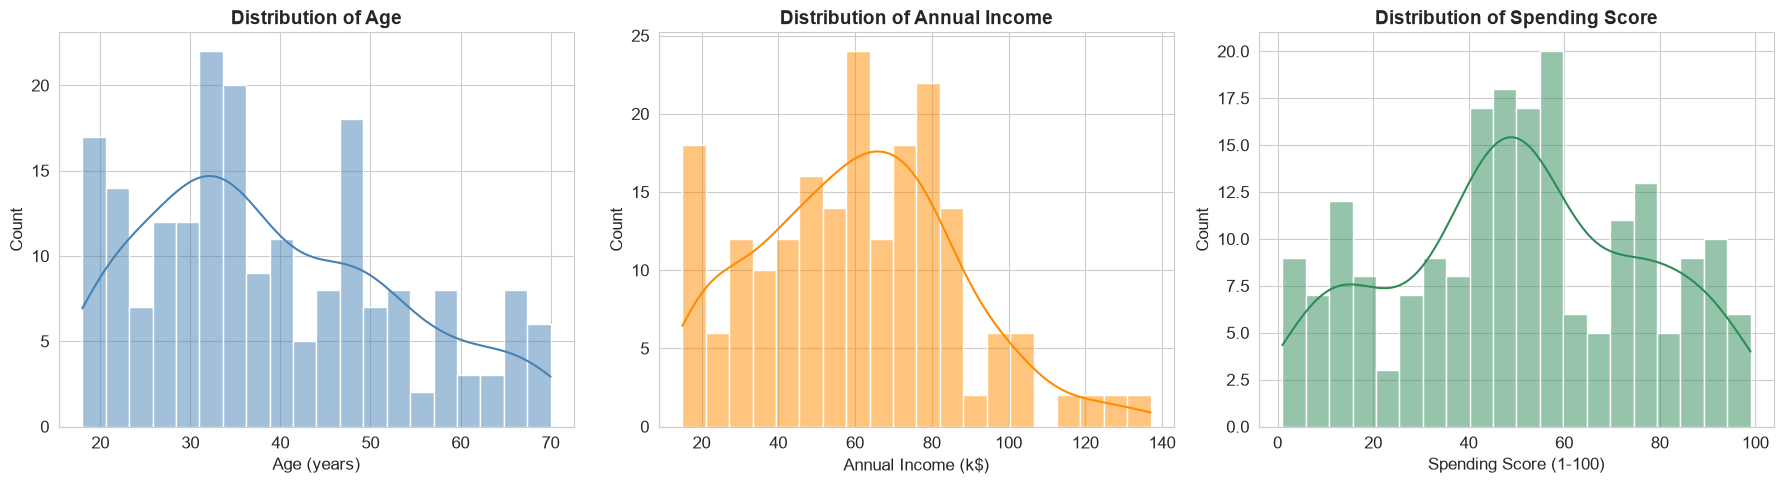

In [4]:
# --- Figure 1: Distribution Plots for Numerical Features ---
# Histograms with KDE (Kernel Density Estimate) overlay show the shape of each distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns of subplots

# Age distribution
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# Annual Income distribution
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Distribution of Annual Income', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Count')

# Spending Score distribution
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Distribution of Spending Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Spending Score (1-100)')
axes[2].set_ylabel('Count')

plt.tight_layout()  # Prevent overlapping labels
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25500\2895677855.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='tab10', ax=axes[0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25500\2895677855.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education', data=df, palette='tab10', ax=axes[1], order=df['Education'].value_counts().index)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25500\2895677855.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Marital Status', data=df, palette='tab10', ax=a

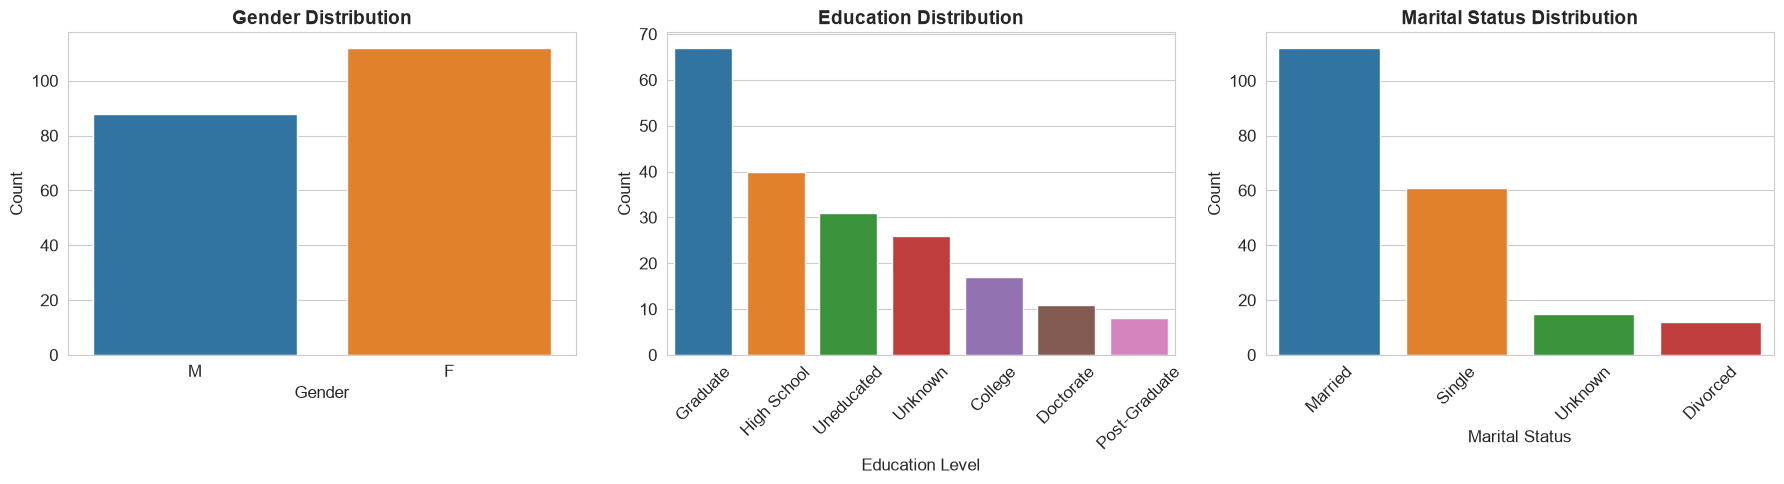

In [5]:
# --- Figure 2: Count Plots for Categorical Features ---
# Bar charts showing the frequency of each category
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

# Gender count
sns.countplot(x='Gender', data=df, palette='tab10', ax=axes[0])
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Education count
sns.countplot(x='Education', data=df, palette='tab10', ax=axes[1], order=df['Education'].value_counts().index)
axes[1].set_title('Education Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)  # Rotate labels for readability

# Marital Status count
sns.countplot(x='Marital Status', data=df, palette='tab10', ax=axes[2], order=df['Marital Status'].value_counts().index)
axes[2].set_title('Marital Status Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Marital Status')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

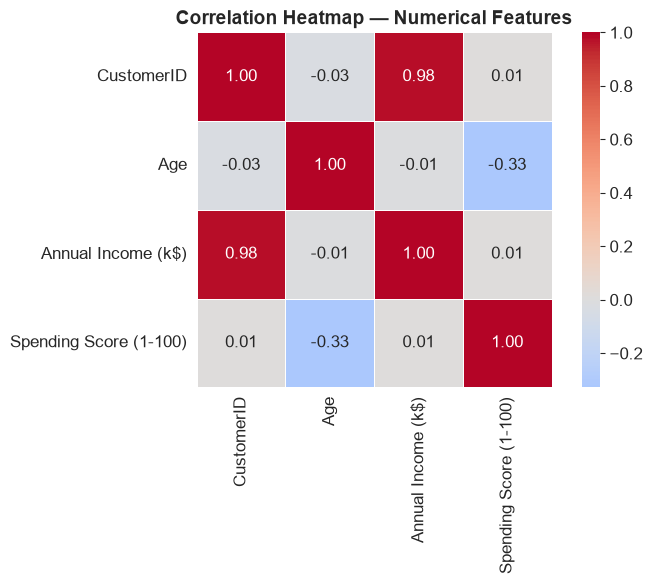

Key observation: CustomerID is just an identifier and will not be used for clustering.
Income and Spending Score have low correlation, making them good independent clustering dimensions.


In [6]:
# --- Figure 3: Correlation Heatmap ---
# Shows linear relationships between numerical features
# Important for checking if features are redundant before clustering
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()  # Get all numeric columns
corr_matrix = df[numerical_cols].corr()  # Compute pairwise Pearson correlation

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print insight
print("Key observation: CustomerID is just an identifier and will not be used for clustering.")
print("Income and Spending Score have low correlation, making them good independent clustering dimensions.")

# Cell 5 — Data Cleaning & Preprocessing

**What:** Handle data quality issues and prepare features for clustering.
**Why:** Clean data is essential for reliable clustering results. We:
1. Keep "Unknown" in Marital Status as a separate meaningful category (not drop it)
2. Verify there are no missing/null values
3. Label-encode categorical columns for optional future use in extended analysis


In [7]:
# --- Step 1: Handle "Unknown" values in Marital Status ---
# "Unknown" is already a distinct category in the data (15 rows)
# We keep it as-is — it represents customers whose marital status is not recorded
print("Marital Status value counts (including 'Unknown' as a valid category):")
print(df['Marital Status'].value_counts())
print(f"\n'Unknown' count in Marital Status: {(df['Marital Status'] == 'Unknown').sum()} rows")

# --- Step 2: Check for null/missing values ---
print("\n" + "=" * 60)
print("NULL VALUE CHECK")
print("=" * 60)
null_counts = df.isnull().sum()  # Count nulls in each column
print(null_counts)
print(f"\nTotal null values in dataset: {df.isnull().sum().sum()}")
if df.isnull().sum().sum() == 0:
    print("No missing values found — dataset is clean!")
else:
    print("Warning: Null values detected. Consider imputation or removal.")

Marital Status value counts (including 'Unknown' as a valid category):
Marital Status
Married     112
Single       61
Unknown      15
Divorced     12
Name: count, dtype: int64

'Unknown' count in Marital Status: 15 rows

NULL VALUE CHECK
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total null values in dataset: 0
No missing values found — dataset is clean!


In [8]:
# --- Step 3: Label Encode Categorical Columns ---
# LabelEncoder converts categorical text labels into integers
# e.g., Gender: M=1, F=0; Education: College=0, Doctorate=1, ...
# This is stored as separate columns for optional use in extended analysis

le_gender = LabelEncoder()       # Encoder for Gender column
le_education = LabelEncoder()    # Encoder for Education column
le_marital = LabelEncoder()      # Encoder for Marital Status column

# Fit and transform each categorical column, creating new encoded columns
df['Gender_enc'] = le_gender.fit_transform(df['Gender'])
df['Education_enc'] = le_education.fit_transform(df['Education'])
df['Marital_Status_enc'] = le_marital.fit_transform(df['Marital Status'])

# Display the mapping for reference
print("Label Encoding Mappings:")
print(f"  Gender:      {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"  Education:   {dict(zip(le_education.classes_, le_education.transform(le_education.classes_)))}")
print(f"  Marital:     {dict(zip(le_marital.classes_, le_marital.transform(le_marital.classes_)))}")
print("\nEncoded dataset preview:")
df.head()

Label Encoding Mappings:
  Gender:      {'F': np.int64(0), 'M': np.int64(1)}
  Education:   {'College': np.int64(0), 'Doctorate': np.int64(1), 'Graduate': np.int64(2), 'High School': np.int64(3), 'Post-Graduate': np.int64(4), 'Uneducated': np.int64(5), 'Unknown': np.int64(6)}
  Marital:     {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2), 'Unknown': np.int64(3)}

Encoded dataset preview:


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Gender_enc,Education_enc,Marital_Status_enc
0,1,M,19,High School,Married,15,39,1,3,1
1,2,M,21,Graduate,Single,15,81,1,2,2
2,3,F,20,Graduate,Married,16,6,0,2,1
3,4,F,23,High School,Unknown,16,77,0,3,3
4,5,F,31,Uneducated,Married,17,40,0,5,1


# Cell 6 — Feature Selection & Scaling

**What:** Select the two core features for clustering and standardize them.
**Why:**
- **Feature Selection:** Annual Income and Spending Score are the most meaningful
  dimensions for customer segmentation — they directly capture purchasing behavior.
- **Scaling:** K-Means and DBSCAN use distance calculations. Without scaling, the
  feature with the larger range would dominate the distance metric. StandardScaler
  transforms each feature to zero mean and unit variance so both contribute equally.

**Topics highlighted:** Scaling, Clustering


In [9]:
# Select the two core clustering features
feature_columns = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[feature_columns].values  # Convert to numpy array for sklearn

print(f"Selected features: {feature_columns}")
print(f"Feature matrix shape: {X.shape}")  # (200 customers, 2 features)

# --- Apply StandardScaler ---
# StandardScaler: z = (x - mean) / std_deviation
# After scaling, each feature has mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Fit the scaler AND transform the data

print(f"\nScaled feature matrix shape: {X_scaled.shape}")
print(f"\nScaled data stats (should be ~0 mean, ~1 std):")
print(f"  Mean:  {X_scaled.mean(axis=0).round(4)}")   # Should be ~0 for both features
print(f"  Std:   {X_scaled.std(axis=0).round(4)}")     # Should be ~1 for both features
print(f"\nFirst 3 scaled samples:\n{X_scaled[:3].round(4)}")

Selected features: ['Annual Income (k$)', 'Spending Score (1-100)']
Feature matrix shape: (200, 2)

Scaled feature matrix shape: (200, 2)

Scaled data stats (should be ~0 mean, ~1 std):
  Mean:  [-0. -0.]
  Std:   [1. 1.]

First 3 scaled samples:
[[-1.739  -0.4348]
 [-1.739   1.1957]
 [-1.7008 -1.7159]]


# Cell 7 — Elbow Method

**What:** Run K-Means for k = 1 to 10 and plot the inertia (within-cluster sum of squares).
**Why:** The Elbow Method helps identify the optimal number of clusters. As k increases,
inertia decreases — but at some point the improvement slows dramatically. That "elbow"
point suggests the best trade-off between cluster compactness and number of clusters.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25500\3251991124.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8, color='steelblue')


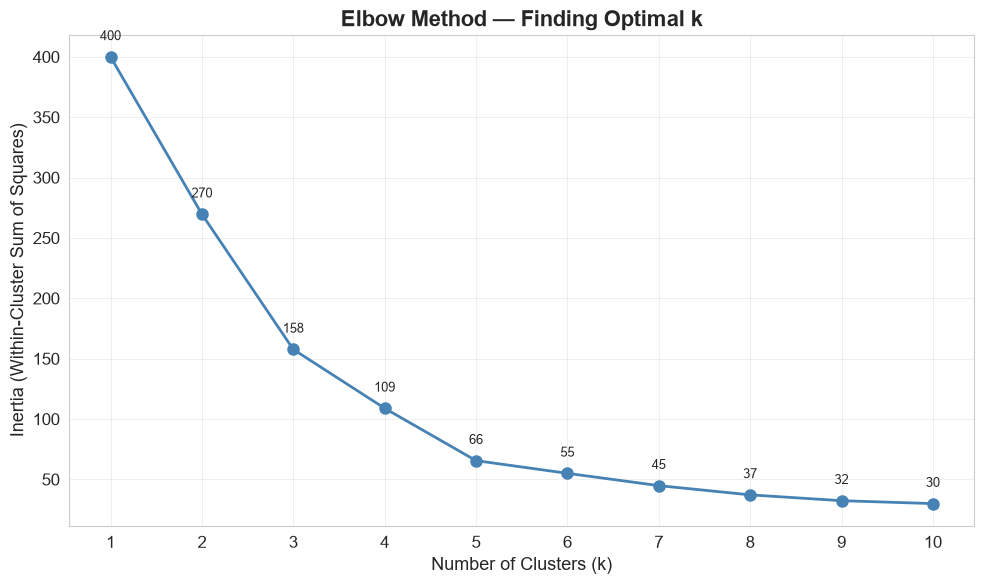

Inertia values per k:
  k=1: Inertia = 400.00
  k=2: Inertia = 269.69
  k=3: Inertia = 157.70
  k=4: Inertia = 108.92
  k=5: Inertia = 65.57
  k=6: Inertia = 55.06
  k=7: Inertia = 44.86
  k=8: Inertia = 37.23
  k=9: Inertia = 32.39
  k=10: Inertia = 29.98


In [10]:
# --- Elbow Method: Compute Inertia for k = 1 to 10 ---
inertia_values = []  # Store inertia for each k
k_range = range(1, 11)  # Test k from 1 to 10

for k in k_range:
    # Initialize KMeans with k clusters, fixed random state for reproducibility
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_scaled)                   # Fit on scaled features
    inertia_values.append(kmeans_elbow.inertia_)  # Inertia = sum of squared distances to nearest centroid

# --- Plot the Elbow Curve ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8, color='steelblue')

# Annotate each point with its inertia value
for k, inertia in zip(k_range, inertia_values):
    plt.annotate(f'{inertia:.0f}', (k, inertia), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9)

plt.title('Elbow Method — Finding Optimal k', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=13)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the inertia values for reference
print("Inertia values per k:")
for k, inertia in zip(k_range, inertia_values):
    print(f"  k={k}: Inertia = {inertia:.2f}")

# Cell 8 — Silhouette Score

**What:** Compute silhouette scores for k = 2 to 10 and identify the optimal k.
**Why:** While the Elbow Method is somewhat subjective, the Silhouette Score provides
a quantitative measure of cluster quality. It ranges from -1 to +1:
- **+1:** Well-separated, compact clusters
- **0:** Cluster boundaries are ambiguous
- **-1:** Points may be assigned to wrong clusters

The k with the **highest silhouette score** is selected as the optimal k and used
programmatically in all subsequent cells (never hardcoded).


SILHOUETTE ANALYSIS RESULTS
Optimal k: 5 (Silhouette Score: 0.5547)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25500\262382800.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(list(k_values), silhouette_scores, 'go-', linewidth=2, markersize=8, color='seagreen')


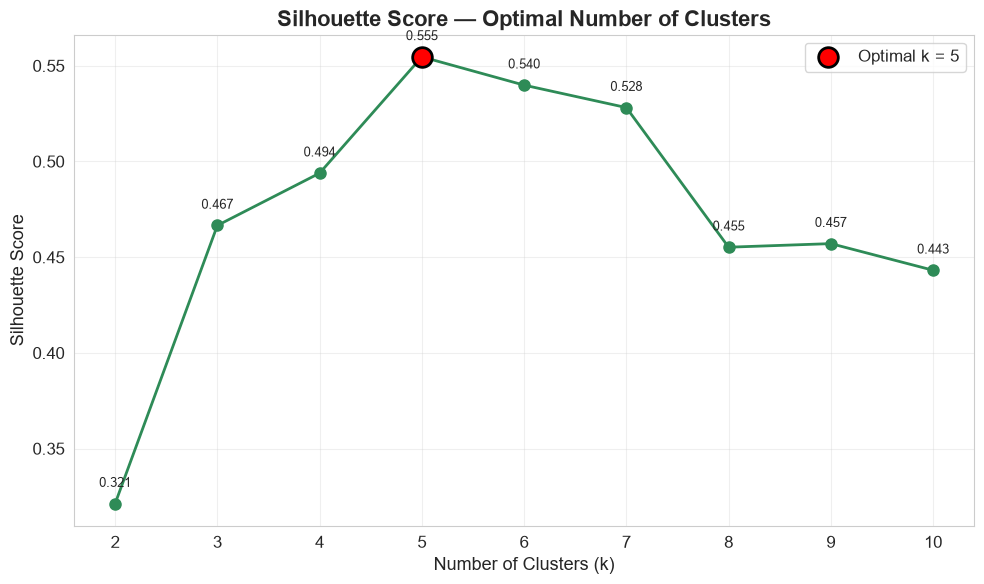


Silhouette scores per k:
  k=2: Score = 0.3213
  k=3: Score = 0.4666
  k=4: Score = 0.4939
  k=5: Score = 0.5547 <-- BEST
  k=6: Score = 0.5399
  k=7: Score = 0.5281
  k=8: Score = 0.4552
  k=9: Score = 0.4571
  k=10: Score = 0.4432


In [11]:
# --- Compute Silhouette Scores for k = 2 to 10 ---
# Note: Silhouette score requires at least 2 clusters (k >= 2)
silhouette_scores = []   # Store silhouette score for each k
k_values = range(2, 11)  # Test k from 2 to 10

for k in k_values:
    # Fit KMeans with k clusters
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_sil.fit_predict(X_scaled)
    # Compute silhouette score: measures how similar each point is to its own cluster
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# --- Determine the Optimal k ---
best_idx = np.argmax(silhouette_scores)       # Index of the maximum score
optimal_k = list(k_values)[best_idx]          # The k value with the highest score
best_score = silhouette_scores[best_idx]      # The highest score value

print(f"{'=' * 50}")
print(f"SILHOUETTE ANALYSIS RESULTS")
print(f"{'=' * 50}")
print(f"Optimal k: {optimal_k} (Silhouette Score: {best_score:.4f})")
print(f"{'=' * 50}")

# --- Plot Silhouette Scores vs k ---
plt.figure(figsize=(10, 6))
plt.plot(list(k_values), silhouette_scores, 'go-', linewidth=2, markersize=8, color='seagreen')

# Highlight the optimal k with a red marker
plt.scatter([optimal_k], [best_score], color='red', s=200, zorder=5,
            edgecolors='black', linewidths=2, label=f'Optimal k = {optimal_k}')

# Annotate each point
for k, score in zip(k_values, silhouette_scores):
    plt.annotate(f'{score:.3f}', (k, score), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9)

plt.title('Silhouette Score — Optimal Number of Clusters', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.xticks(list(k_values))
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print all scores for reference
print("\nSilhouette scores per k:")
for k, score in zip(k_values, silhouette_scores):
    marker = " <-- BEST" if k == optimal_k else ""
    print(f"  k={k}: Score = {score:.4f}{marker}")

# Cell 9 — K-Means Clustering

## What is Unsupervised Learning?
**Unsupervised learning** is a type of machine learning where the model works with
**unlabeled data** — there is no predefined "correct answer" to learn from. Instead,
the algorithm discovers hidden patterns and structures within the data on its own.

## What is Clustering?
**Clustering** is the task of grouping similar data points together so that items
within the same group (cluster) are more similar to each other than to those in
other groups. It is one of the most common unsupervised learning techniques.

## Why K-Means?
**K-Means** is chosen for this task because:
1. **Simplicity:** Easy to understand and implement
2. **Efficiency:** Computationally fast, scales well to large datasets
3. **Effectiveness:** Works well when clusters are roughly spherical and similar in size
4. **Interpretability:** Cluster centroids provide clear reference points
5. **Fit for this data:** Customer data with Income and Spending Score forms
   naturally distinct groups that align with K-Means' assumptions

The algorithm works by:
1. Randomly placing k centroids in the feature space
2. Assigning each point to the nearest centroid
3. Recalculating centroids as the mean of assigned points
4. Repeating steps 2-3 until convergence

**Topics highlighted:** Clustering, Unsupervised Learning


In [12]:
# --- Fit K-Means with the Optimal k ---
# optimal_k was determined programmatically from the Silhouette Score in Cell 8
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# fit_predict: fit the model AND return cluster labels for each data point
df['Cluster'] = kmeans.fit_predict(X_scaled)

# --- Display Cluster Assignment Results ---
print(f"K-Means Clustering Results (k = {optimal_k})")
print(f"{'=' * 45}")
print(f"Cluster assignments added to DataFrame as 'Cluster' column")
print(f"\nCluster size distribution:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = count / len(df) * 100
    print(f"  Cluster {cluster}: {count} customers ({percentage:.1f}%)")

print(f"\nTotal customers clustered: {len(df)}")
print(f"Centroid locations (scaled coordinates):\n{kmeans.cluster_centers_.round(4)}")

K-Means Clustering Results (k = 5)
Cluster assignments added to DataFrame as 'Cluster' column

Cluster size distribution:
  Cluster 0: 81 customers (40.5%)
  Cluster 1: 39 customers (19.5%)
  Cluster 2: 22 customers (11.0%)
  Cluster 3: 35 customers (17.5%)
  Cluster 4: 23 customers (11.5%)

Total customers clustered: 200
Centroid locations (scaled coordinates):
[[-0.2009 -0.0265]
 [ 0.9916  1.2395]
 [-1.3295  1.1322]
 [ 1.055  -1.2844]
 [-1.3075 -1.137 ]]


# Cell 10 — Cluster Visualization (2D)

**What:** Create a 2D scatter plot showing customer segments colored by cluster label.
**Why:** This is the **primary visualization** of the task — it直观 shows how customers
are grouped based on their Annual Income and Spending Score. The plot reveals distinct
customer segments that the business can target with different strategies.

Centroids are plotted as large black X markers to show the "center" of each segment.


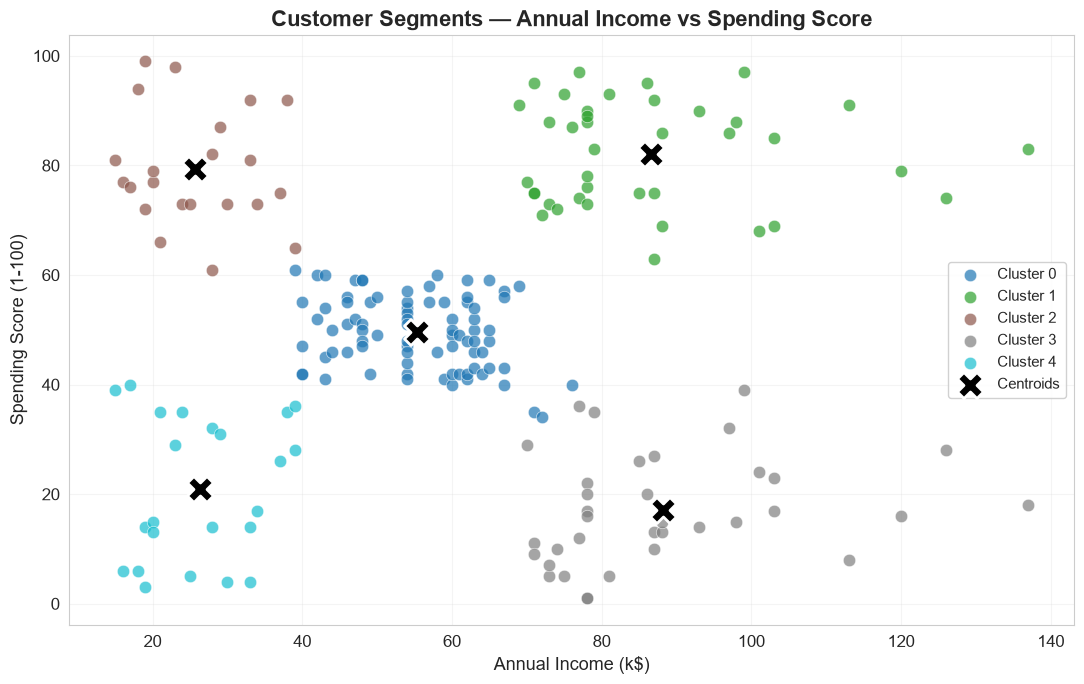

In [13]:
# --- 2D Scatter Plot: Customer Segments ---
# Use a consistent color palette from tab10
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))  # Generate k distinct colors

plt.figure(figsize=(11, 7))

# Plot each cluster with a distinct color
for cluster_id in range(optimal_k):
    # Filter data points belonging to this cluster
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=[colors[cluster_id]],              # Single color for this cluster
                label=f'Cluster {cluster_id}',       # Legend entry
                s=80,                                 # Marker size
                alpha=0.7,                            # Slight transparency for overlap
                edgecolors='white',                   # White edge for visibility
                linewidths=0.5)

# Plot centroids as large black X markers
# Transform centroids back to original scale for meaningful plotting
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=350, linewidths=2, edgecolors='white',
            label='Centroids', zorder=5)  # zorder=5 ensures centroids are on top

# --- Labels and Title ---
plt.title('Customer Segments — Annual Income vs Spending Score', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Cell 11 — Cluster Analysis & Average Spending

**What:** Profile each cluster by computing average demographics and behavioral metrics,
and visualize average spending per cluster.
**Why:** Understanding what each cluster "looks like" enables actionable business
decisions — e.g., targeting high-income low-spenders with promotions, or offering
premium products to young high-spenders.

**Bonus:** A dedicated bar chart showing Average Spending Score per Cluster, sorted
in descending order, provides an at-a-glance spending comparison.


In [14]:
# --- Part A: Cluster Profiles — Mean Values ---
# Group by cluster and compute mean of key numerical features
cluster_profiles = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)

print("Cluster Profiles — Average Values:")
print("=" * 65)
# Display as a styled dataframe with gradient coloring
styled_profiles = cluster_profiles.style.background_gradient(cmap='YlOrRd', axis=0)
styled_profiles

Cluster Profiles — Average Values:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.720000,55.300000,49.520000
1,32.690000,86.540000,82.130000
2,25.270000,25.730000,79.360000
3,41.110000,88.200000,17.110000
4,45.220000,26.300000,20.910000


In [15]:
# --- Part B: Gender Distribution Per Cluster ---
print("Gender Distribution per Cluster:")
print("=" * 45)
gender_dist = df.groupby('Cluster')['Gender'].value_counts().unstack(fill_value=0)
gender_dist['Total'] = gender_dist.sum(axis=1)
gender_dist['% Female'] = (gender_dist.get('F', 0) / gender_dist['Total'] * 100).round(1)
gender_dist['% Male'] = (gender_dist.get('M', 0) / gender_dist['Total'] * 100).round(1)
print(gender_dist)

# --- Part C: Education Distribution Per Cluster ---
print("\n\nEducation Distribution per Cluster:")
print("=" * 45)
edu_dist = df.groupby('Cluster')['Education'].value_counts().unstack(fill_value=0)
print(edu_dist)

Gender Distribution per Cluster:
Gender    F   M  Total  % Female  % Male
Cluster                                 
0        48  33     81      59.3    40.7
1        21  18     39      53.8    46.2
2        13   9     22      59.1    40.9
3        16  19     35      45.7    54.3
4        14   9     23      60.9    39.1


Education Distribution per Cluster:
Education  College  Doctorate  Graduate  High School  Post-Graduate  \
Cluster                                                               
0                5          6        31           16              3   
1                4          2        13            6              2   
2                2          1         7            4              0   
3                4          1         8           10              2   
4                2          1         8            4              1   

Education  Uneducated  Unknown  
Cluster                         
0                   8       12  
1                   8        4  
2           

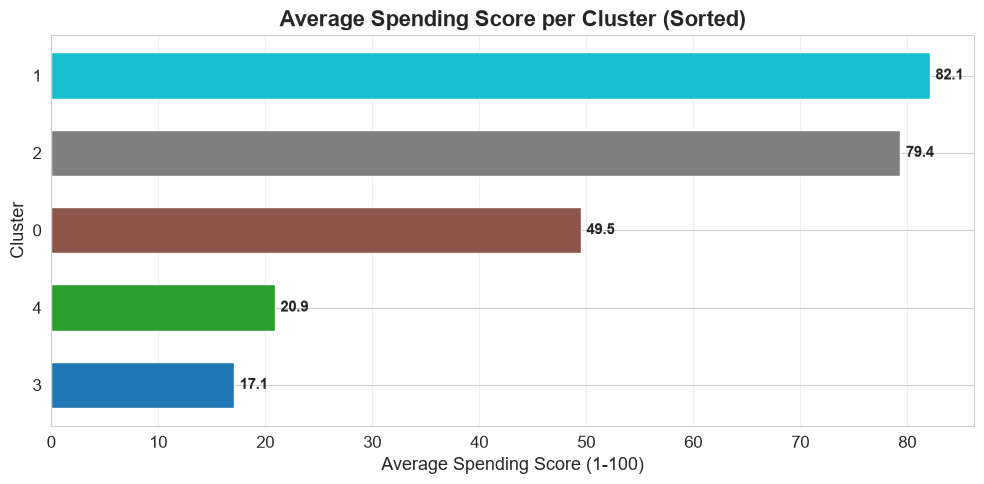

In [16]:
# --- Part D: Average Spending Score per Cluster (Bar Chart) ---
# Bonus visualization: sorted bar chart showing spending behavior across clusters
avg_spending = df.groupby('Cluster')['Spending Score (1-100)'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(avg_spending.index.astype(str), avg_spending.values,
                color=plt.cm.tab10(np.linspace(0, 1, len(avg_spending))),
                edgecolor='white', height=0.6)

# Annotate each bar with its value
for bar, val in zip(bars, avg_spending.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}', va='center', fontsize=11, fontweight='bold')

plt.title('Average Spending Score per Cluster (Sorted)', fontsize=16, fontweight='bold')
plt.xlabel('Average Spending Score (1-100)', fontsize=13)
plt.ylabel('Cluster', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# --- Part E: Cluster Interpretations ---
# Generate interpretations dynamically based on cluster profiles
print("=" * 70)
print("CLUSTER INTERPRETATIONS")
print("=" * 70)

for cluster_id in sorted(df['Cluster'].unique()):
    # Get this cluster's mean values
    profile = df[df['Cluster'] == cluster_id]
    avg_age = profile['Age'].mean()
    avg_income = profile['Annual Income (k$)'].mean()
    avg_spending = profile['Spending Score (1-100)'].mean()
    count = len(profile)

    # Determine income level
    income_label = "High" if avg_income > 60 else ("Low" if avg_income < 40 else "Medium")
    # Determine spending level
    spending_label = "High" if avg_spending > 60 else ("Low" if avg_spending < 40 else "Medium")
    # Determine age group
    age_label = "Young" if avg_age < 30 else ("Middle-aged" if avg_age < 45 else "Older")

    print(f"\nCluster {cluster_id} ({count} customers):")
    print(f"  Income: {income_label} (${avg_income:.1f}k) | Spending: {spending_label} ({avg_spending:.1f}) | Age: {age_label} ({avg_age:.1f} yrs)")
    print(f"  Profile: {age_label} {income_label}-income, {spending_label}-spending customers")

CLUSTER INTERPRETATIONS

Cluster 0 (81 customers):
  Income: Medium ($55.3k) | Spending: Medium (49.5) | Age: Middle-aged (42.7 yrs)
  Profile: Middle-aged Medium-income, Medium-spending customers

Cluster 1 (39 customers):
  Income: High ($86.5k) | Spending: High (82.1) | Age: Middle-aged (32.7 yrs)
  Profile: Middle-aged High-income, High-spending customers

Cluster 2 (22 customers):
  Income: Low ($25.7k) | Spending: High (79.4) | Age: Young (25.3 yrs)
  Profile: Young Low-income, High-spending customers

Cluster 3 (35 customers):
  Income: High ($88.2k) | Spending: Low (17.1) | Age: Middle-aged (41.1 yrs)
  Profile: Middle-aged High-income, Low-spending customers

Cluster 4 (23 customers):
  Income: Low ($26.3k) | Spending: Low (20.9) | Age: Older (45.2 yrs)
  Profile: Older Low-income, Low-spending customers


# Cell 12 — DBSCAN (Bonus)

**What:** Apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
as an alternative clustering algorithm.
**Why:** Unlike K-Means, DBSCAN:
- Does **not** require specifying the number of clusters beforehand
- Can find **arbitrarily shaped** clusters (not just spherical)
- Naturally identifies **noise/outlier points** (label = -1)
- Works well when clusters have varying densities

**Parameters:**
- `eps`: Maximum distance between two points for them to be considered neighbors
- `min_samples`: Minimum number of points required to form a dense region (core point)


In [18]:
# --- Apply DBSCAN Clustering ---
# eps and min_samples are tuned for the scaled 2D feature space
# eps=0.35 means points within 0.35 standard deviations are neighbors
# min_samples=5 means at least 5 points needed to form a cluster core
dbscan = DBSCAN(eps=0.35, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)  # -1 label = noise point

# Count clusters (excluding noise label -1)
n_clusters_dbscan = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN Clustering Results:")
print(f"{'=' * 45}")
print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Noise points (label -1):  {n_noise}")
print(f"\nCluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Clustering Results:
Number of clusters found: 6
Noise points (label -1):  23

Cluster distribution:
DBSCAN_Cluster
-1    23
 0    16
 1    12
 2     7
 3    88
 4    31
 5    23
Name: count, dtype: int64


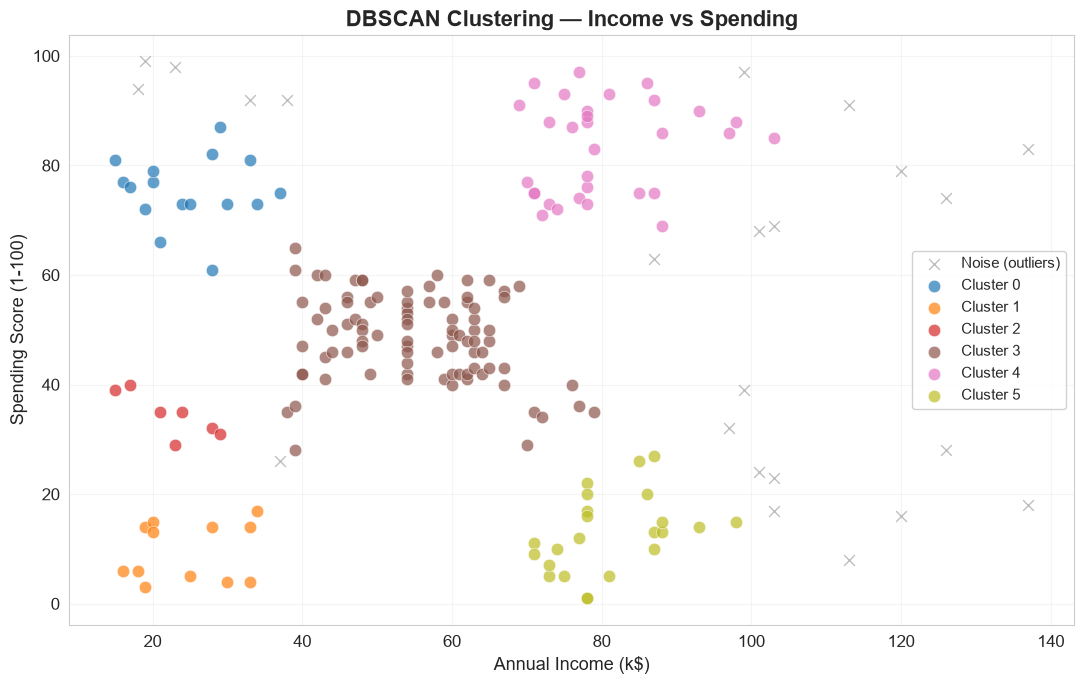

In [19]:
# --- DBSCAN Visualization (2D) ---
# Same style as Cell 10 for easy comparison
plt.figure(figsize=(11, 7))

# Get unique cluster labels (excluding noise)
unique_labels = sorted(df['DBSCAN_Cluster'].unique())
dbscan_colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

for label in unique_labels:
    if label == -1:
        # Noise points: plot in gray with distinct marker and transparency
        noise_data = df[df['DBSCAN_Cluster'] == -1]
        plt.scatter(noise_data['Annual Income (k$)'],
                    noise_data['Spending Score (1-100)'],
                    c='gray', marker='x', s=60, alpha=0.5,
                    label='Noise (outliers)', linewidths=1)
    else:
        # Regular cluster points
        cluster_data = df[df['DBSCAN_Cluster'] == label]
        color_idx = label % len(dbscan_colors)
        plt.scatter(cluster_data['Annual Income (k$)'],
                    cluster_data['Spending Score (1-100)'],
                    c=[dbscan_colors[color_idx]],
                    label=f'Cluster {label}',
                    s=80, alpha=0.7, edgecolors='white', linewidths=0.5)

plt.title('DBSCAN Clustering — Income vs Spending', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [20]:
# --- K-Means vs DBSCAN Comparison ---
# Print a summary comparison for the markdown cell below
print("Comparison complete. See markdown cell below for analysis.")

Comparison complete. See markdown cell below for analysis.


### K-Means vs DBSCAN — Comparison

| Aspect | K-Means | DBSCAN |
|--------|---------|--------|
| **Number of clusters** | `optimal_k` (from Silhouette Score) | Varies (density-dependent) |
| **Noise handling** | No — every point is assigned to a cluster | Yes — identifies noise/outlier points (label -1) |
| **Cluster shape** | Assumes spherical clusters | Can find arbitrary shapes |
| **Input requirement** | Must specify k beforehand | No k needed — derived from density |

**Key Takeaway:** K-Means provides clean, well-defined segments suitable for business
strategy, while DBSCAN reveals density patterns and potential outliers that may warrant
further investigation. The number of clusters found differs because the algorithms use
fundamentally different approaches — distance-to-centroid (K-Means) vs density-reachability (DBSCAN).

> **Note:** Run the cells above to see exact cluster counts and noise point counts for each algorithm.


# Cell 13 — Gradio Interactive App

**What:** Build an interactive web interface using Gradio where users can explore
different clustering configurations in real-time.
**Why:** Gradio allows non-technical stakeholders (marketing teams, business analysts)
to interact with the clustering model without writing code. They can:
- Switch between K-Means and DBSCAN algorithms
- Adjust the number of clusters (for K-Means) using a slider
- View the resulting scatter plot, cluster summary, and spending bar chart

This makes the analysis **accessible, reproducible, and actionable**.


In [21]:
# --- Define Helper Functions for the Gradio App ---

def run_clustering(algorithm, n_clusters):
    """
    Main function called by the Gradio interface.

    Args:
        algorithm: 'K-Means' or 'DBSCAN'
        n_clusters: Number of clusters (used only for K-Means)

    Returns:
        scatter_plot: Matplotlib figure with cluster scatter plot
        summary_table: DataFrame with cluster averages
        spending_chart: Matplotlib figure with average spending bar chart
    """

    # --- Step 1: Fit the selected algorithm ---
    if algorithm == 'K-Means':
        # Fit KMeans with user-selected number of clusters
        model = KMeans(n_clusters=int(n_clusters), random_state=42, n_init=10)
        labels = model.fit_predict(X_scaled)
    else:
        # Fit DBSCAN with tuned parameters
        model = DBSCAN(eps=0.35, min_samples=5)
        labels = model.fit_predict(X_scaled)

    # --- Step 2: Create Scatter Plot ---
    fig_scatter, ax_scatter = plt.subplots(figsize=(9, 6))
    unique_labels = sorted(set(labels))
    plot_colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

    for idx, label in enumerate(unique_labels):
        mask = labels == label
        if label == -1:
            # Noise points (DBSCAN only): gray with 'x' marker
            ax_scatter.scatter(X[mask, 0], X[mask, 1], c='gray', marker='x',
                               s=60, alpha=0.5, label='Noise')
        else:
            # Regular clusters: colored dots
            ax_scatter.scatter(X[mask, 0], X[mask, 1],
                               c=[plot_colors[idx % len(plot_colors)]],
                               s=80, alpha=0.7, edgecolors='white', linewidths=0.5,
                               label=f'Cluster {label}')

    # Plot centroids for K-Means
    if algorithm == 'K-Means':
        centroids_orig = scaler.inverse_transform(model.cluster_centers_)
        ax_scatter.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                           c='black', marker='X', s=300, linewidths=2,
                           edgecolors='white', label='Centroids', zorder=5)

    ax_scatter.set_title(f'{algorithm} — Customer Segments', fontsize=14, fontweight='bold')
    ax_scatter.set_xlabel('Annual Income (k$)', fontsize=12)
    ax_scatter.set_ylabel('Spending Score (1-100)', fontsize=12)
    ax_scatter.legend(fontsize=10, loc='best')
    ax_scatter.grid(True, alpha=0.2)
    plt.tight_layout()

    # --- Step 3: Create Summary Table ---
    temp_df = df.copy()
    temp_df['Cluster'] = labels
    summary = temp_df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
    summary['Count'] = temp_df.groupby('Cluster').size().values
    summary = summary[['Count', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
    summary.columns = ['Count', 'Avg Age', 'Avg Income (k$)', 'Avg Spending Score']
    summary = summary.reset_index()

    # --- Step 4: Create Average Spending Bar Chart ---
    fig_bar, ax_bar = plt.subplots(figsize=(8, 4))
    avg_sp = temp_df.groupby('Cluster')['Spending Score (1-100)'].mean().sort_values(ascending=True)
    bar_colors = plt.cm.tab10(np.linspace(0, 1, len(avg_sp)))
    bars = ax_bar.barh(avg_sp.index.astype(str), avg_sp.values,
                       color=bar_colors, edgecolor='white', height=0.6)

    for bar, val in zip(bars, avg_sp.values):
        ax_bar.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

    ax_bar.set_title('Avg Spending Score per Cluster', fontsize=13, fontweight='bold')
    ax_bar.set_xlabel('Average Spending Score', fontsize=11)
    ax_bar.set_ylabel('Cluster', fontsize=11)
    ax_bar.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    return fig_scatter, summary, fig_bar


# --- Build the Gradio Interface with gr.Blocks ---
with gr.Blocks(title="Customer Segmentation Explorer", theme=gr.themes.Soft()) as demo:
    # Page title and description
    gr.Markdown("""
    # 🎯 Customer Segmentation Explorer

    Select an algorithm and adjust parameters to explore different customer segments.

    - **K-Means:** Choose the number of clusters with the slider
    - **DBSCAN:** Uses density-based clustering (no cluster count needed)
    """)

    with gr.Row():
        # --- Left Column: Controls ---
        with gr.Column(scale=1):
            algorithm_selector = gr.Radio(
                choices=['K-Means', 'DBSCAN'],
                value='K-Means',
                label='Clustering Algorithm',
                info='Select K-Means or DBSCAN'
            )
            cluster_slider = gr.Slider(
                minimum=2, maximum=10,
                value=float(optimal_k),   # Default to the optimal k from Silhouette Score
                step=1,
                label=f'Number of Clusters (K-Means only) — Default: {optimal_k}',
                info='Adjust the number of clusters for K-Means'
            )
            run_button = gr.Button("Run Clustering", variant="primary", size="lg")

        # --- Right Column: Outputs ---
        with gr.Column(scale=2):
            scatter_output = gr.Image(label="Cluster Scatter Plot", type="filepath")
            table_output = gr.Dataframe(label="Cluster Summary")
            bar_output = gr.Image(label="Average Spending per Cluster", type="filepath")

    # --- Wire up the button click to the clustering function ---
    def run_and_return_images(algorithm, n_clusters):
        """Wrapper that runs clustering and saves plots as images for Gradio."""
        fig_scatter, summary, fig_bar = run_clustering(algorithm, n_clusters)

        # Save scatter plot to a temporary file
        import tempfile, os
        scatter_path = os.path.join(tempfile.gettempdir(), 'scatter_plot.png')
        fig_scatter.savefig(scatter_path, dpi=100, bbox_inches='tight')
        plt.close(fig_scatter)

        # Save bar chart to a temporary file
        bar_path = os.path.join(tempfile.gettempdir(), 'bar_chart.png')
        fig_bar.savefig(bar_path, dpi=100, bbox_inches='tight')
        plt.close(fig_bar)

        return scatter_path, summary, bar_path

    # Connect button to function
    run_button.click(
        fn=run_and_return_images,
        inputs=[algorithm_selector, cluster_slider],
        outputs=[scatter_output, table_output, bar_output]
    )

# --- Launch the Gradio App ---
# share=True creates a public URL for sharing (requires internet)
demo.launch(share=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25500\2030217638.py:89: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Customer Segmentation Explorer", theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
